In [19]:
import os
from pathlib import Path
import sys
import json
import time
import torch
from torchvision.ops import box_iou as tv_box_iou
import numpy as np
from PIL import Image as PILImage
from tqdm.notebook import tqdm as tnb # Use tnb for clarity inside function
from torchvision.transforms import functional as TF2

print("Re-initializing environment variables and loading model for testing...")

# Re-define constants (from tCAULNZ8W5j7)
BASE_DIR = Path("/content/drive/MyDrive/mobilenetv3_step2")
DATASET_ROOT = BASE_DIR / "fall_dataset"
CODE_DIR     = BASE_DIR / "person_detector_code"
RUNS_DIR     = BASE_DIR / "person_detector_runs"
CROPS_DIR    = BASE_DIR / "person_crops"

RUN_NAME = "run1"

# Using the last known SCORE_THRESH from kernel state (0.35)
SCORE_THRESH_INITIAL = 0.35
NMS_IOU      = 0.45
INPUT_SIZE   = 640

# Add CODE_DIR to sys.path and import necessary modules (from us0CRSWohUG2)
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
from model import PersonDetector

# Define device (from J22qJUCZmBAS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Initialize model (from yoYjeq6cowWZ)
model = PersonDetector(
    pretrained=True,
    input_size=INPUT_SIZE
).to(device)

# Define run_dir and checkpoint paths (from 4v0QFU2Fo4Kt)
run_dir = RUNS_DIR / RUN_NAME
ckpt_best = run_dir / "best.pt"

print(f"Checkpoints directory: {run_dir}")
print(f"Best checkpoint path: {ckpt_best}")

# Load the best model weights (from NzXWxJpgOveI)
try:
    ck = torch.load(ckpt_best, map_location=device)
    model.load_state_dict(ck['model'])
    model.eval() # Set model to evaluation mode
    print(f'Loaded best.pt  (epoch {ck["epoch"]}  best_val_mAP50={ck["best_map50"]:.4f})')
except FileNotFoundError:
    print(f"Error: {ckpt_best} not found. Please ensure training was completed and the checkpoint exists.")
    # Exit or handle error appropriately if model loading is critical
    # For now, we'll continue, but subsequent steps might fail if model isn't loaded.
except Exception as e:
    print(f"An error occurred while loading the model: {e}")

# Define run_test_metrics function (from y8YoO1tkOx-O)
IMAGE_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}

def load_gt_boxes(label_path):
    """Load YOLO label -> (N,4) cx cy w h tensor."""
    boxes = []
    if label_path and Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) >= 5:
                    boxes.append(list(map(float, p[1:5])))
    return torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros(0,4)

def cxcywh_to_xyxy(boxes):
    """(N,4) cx cy w h -> x1 y1 x2 y2  (normalised)."""
    if boxes.numel() == 0: return boxes
    return torch.stack([
        boxes[:,0]-boxes[:,2]/2,
        boxes[:,1]-boxes[:,3]/2,
        boxes[:,0]+boxes[:,2]/2,
        boxes[:,1]+boxes[:,3]/2,
    ], dim=1)

def run_test_metrics(model, dataset_root, split='test',
                     score_thresh=0.35, nms_iou=0.45,
                     iou_match_thresh=0.5):
    """
    Returns a dict with full test-set metrics + per-image records.
    """
    img_dir = Path(dataset_root) / split / 'images'
    lbl_dir = Path(dataset_root) / split / 'labels'
    img_paths = sorted(p for p in img_dir.iterdir()
                       if p.suffix.lower() in IMAGE_EXTS)

    all_ious        = []   # IoU of every matched TP pred
    all_scores      = []   # (score, is_tp) for mAP
    per_image       = []   # per-image breakdown
    n_gt_total      = 0
    n_tp = n_fp = n_fn = 0

    model.eval()

    for img_path in tnb(img_paths, desc=f'Evaluating {split}'):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        gt_cxywh = load_gt_boxes(lbl_path)          # (N,4) norm cxcywh
        gt_xyxy  = cxcywh_to_xyxy(gt_cxywh)         # (N,4) norm xyxy
        n_gt     = gt_xyxy.size(0)
        n_gt_total += n_gt

        # run detector
        img = PILImage.open(img_path).convert('RGB')
        # W, H = img.size # Not strictly needed here, INPUT_SIZE is used below

        # Moved TF2 import inside to ensure it's available
        t = TF2.normalize(
            TF2.to_tensor(TF2.resize(img, [INPUT_SIZE, INPUT_SIZE])),
            [0.485,0.456,0.406], [0.229,0.224,0.225]
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            preds = model(t)
            dets  = model.decode(preds, INPUT_SIZE, INPUT_SIZE,
                                 score_thresh=score_thresh, nms_iou=nms_iou)

        pred_boxes  = dets[0]['boxes']    # (K,4) xyxy norm
        pred_scores = dets[0]['scores']   # (K,)
        n_pred      = pred_boxes.size(0)

        img_iou_list  = []
        img_tp = img_fp = img_fn = 0

        if n_pred == 0 and n_gt == 0:
            pass
        elif n_pred == 0:
            img_fn    = n_gt
            n_fn     += n_gt
        elif n_gt == 0:
            img_fp    = n_pred
            n_fp     += n_pred
            for s in pred_scores:
                all_scores.append((s.item(), 0))
        else:
            gt_xyxy_dev = gt_xyxy.to(device)
            iou_mat     = tv_box_iou(pred_boxes, gt_xyxy_dev)  # (K, N)
            matched_gt  = set()

            for ki in pred_scores.argsort(descending=True):
                best_iou, best_j = iou_mat[ki].max(dim=0)
                bv = best_iou.item()
                bj = best_j.item()
                if bv >= iou_match_thresh and bj not in matched_gt:
                    all_scores.append((pred_scores[ki].item(), 1))
                    all_ious.append(bv)
                    img_iou_list.append(bv)
                    matched_gt.add(bj)
                    img_tp += 1
                else:
                    all_scores.append((pred_scores[ki].item(), 0))
                    img_fp += 1

            img_fn  = n_gt - len(matched_gt)
            n_tp   += img_tp
            n_fp   += img_fp
            n_fn   += img_fn

        per_image.append(dict(
            path      = str(img_path),
            n_gt      = n_gt,
            n_pred    = n_pred,
            tp        = img_tp,
            fp        = img_fp,
            fn        = img_fn,
            mean_iou  = float(np.mean(img_iou_list)) if img_iou_list else 0.0,
            gt_cxywh  = gt_cxywh,
            pred_boxes= pred_boxes.cpu(),
            scores    = pred_scores.cpu(),
        ))

    # mAP@0.5 calculation
    ap50 = 0.0
    if all_scores:
        all_scores.sort(key=lambda x: -x[0])
        tp_c  = torch.tensor([x[1] for x in all_scores], dtype=torch.float32).cumsum(0)
        fp_c  = (1-torch.tensor([x[1] for x in all_scores], dtype=torch.float32)).cumsum(0)
        prec  = tp_c / (tp_c + fp_c).clamp(min=1e-6) # Use min for clamp
        rec   = tp_c / max(n_gt_total, 1)
        ap50  = sum(prec[rec>=t].max().item() if (rec>=t).any() else 0.0
                    for t in torch.linspace(0,1,101)) / 101.0

    precision = n_tp / max(n_tp + n_fp, 1)
    recall    = n_tp / max(n_tp + n_fn, 1)
    f1        = 2*precision*recall / max(precision+recall, 1e-6)
    avg_iou   = float(np.mean(all_ious)) if all_ious else 0.0

    return dict(
        mAP50     = ap50,
        avg_iou   = avg_iou,
        precision = precision,
        recall    = recall,
        f1        = f1,
        n_gt      = n_gt_total,
        n_tp      = n_tp,
        n_fp      = n_fp,
        n_fn      = n_fn,
        all_ious  = all_ious,
        per_image = per_image,
    )

print("✅ Environment re-initialized and best model loaded. `run_test_metrics` defined.")

# ── Score threshold sweep on VAL (not test) ────────────────────── (from QKvDNdhlPLPo)
print('\nScore threshold sweep on VAL set:')
print(f'{"Thresh":>8}  {"Prec":>7}  {"Recall":>7}  {"F1":>7}  {"AvgIoU":>8}')
print('─' * 48)

best_f1_thresh = SCORE_THRESH_INITIAL # Use the initial score thresh here
best_f1_val    = 0.0
sweep_results  = []

# Ensure 'val' split exists before attempting to sweep
val_images_dir = DATASET_ROOT / 'val' / 'images'
if val_images_dir.exists() and len(list(val_images_dir.iterdir())) > 0:
    for thresh in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
        r = run_test_metrics(model, DATASET_ROOT, split='val',   # ← val, not test
                             score_thresh=thresh, nms_iou=NMS_IOU)
        marker = '  ← current' if thresh == SCORE_THRESH_INITIAL else ''
        if r['f1'] > best_f1_val:
            best_f1_val    = r['f1']
            best_f1_thresh = thresh
        sweep_results.append(r)
        print(f'  {thresh:.2f}     {r["precision"]:.4f}   {r["recall"]:.4f}   ' \
              f'{r["f1"]:.4f}   {r["avg_iou"]:.4f}{marker}')

    print(f'\n  ⭐  Best F1 threshold (from val) = {best_f1_thresh:.2f}  ' \
          f'(F1={best_f1_val:.4f})')
    print(f'     Using this threshold for final test eval and crop export')

else:
    print("Warning: Validation split not found or is empty. Skipping score threshold sweep and using initial SCORE_THRESH.")
    best_f1_thresh = SCORE_THRESH_INITIAL
    # If validation data is not available, we can't determine best_f1_val, so we'll set it to 0.0
    best_f1_val = 0.0


# ── Now run test exactly ONCE with the chosen threshold ─────────── (from OnUUt5htp2Da)
print(f'\nFinal test evaluation at threshold={best_f1_thresh:.2f}:')
final_test = run_test_metrics(model, DATASET_ROOT, split='test',
                              score_thresh=best_f1_thresh, nms_iou=NMS_IOU)

# Print detailed metrics as requested by the user
print('\n' + '='*52)
print('  TEST SET METRICS')
print('='*52)
print(f'  mAP @ IoU=0.50        : {final_test["mAP50"]:.4f}')
print(f'  Average IoU (TP only) : {final_test["avg_iou"]:.4f}')
print(f'  Precision             : {final_test["precision"]:.4f}')
print(f'  Recall                : {final_test["recall"]:.4f}')
print(f'  F1 Score              : {final_test["f1"]:.4f}')
print('─'*52)
print(f'  Total GT boxes        : {final_test["n_gt"]}')
print(f'  True  Positives (TP)  : {final_test["n_tp"]}')
print(f'  False Positives (FP)  : {final_test["n_fp"]}  ← ghost detections')
print(f'  False Negatives (FN)  : {final_test["n_fn"]}  ← missed persons')
print('='*52)

# Update SCORE_THRESH for consistency if needed for later steps
SCORE_THRESH = best_f1_thresh # This updates the global SCORE_THRESH if it's used elsewhere
print(f'\nSCORE_THRESH updated to {SCORE_THRESH} for consistency with final test eval ✅')


Re-initializing environment variables and loading model for testing...
Device: cpu
Checkpoints directory: /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1
Best checkpoint path: /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1/best.pt
Loaded best.pt  (epoch 20  best_val_mAP50=0.8267)
✅ Environment re-initialized and best model loaded. `run_test_metrics` defined.

Score threshold sweep on VAL set:
  Thresh     Prec   Recall       F1    AvgIoU
────────────────────────────────────────────────


Evaluating val:   0%|          | 0/111 [00:00<?, ?it/s]

  0.15     0.0029   0.9912   0.0058   0.7383


Evaluating val:   0%|          | 0/111 [00:00<?, ?it/s]

  0.20     0.0293   0.9474   0.0569   0.7410


...

  0.55     0.8713   0.7719   0.8186   0.7568


Evaluating val:   0%|          | 0/111 [00:00<?, ?it/s]

  0.60     0.9524   0.7018   0.8081   0.7607

  ⭐  Best F1 threshold (from val) = 0.55  (F1=0.8186)
     Using this threshold for final test eval and crop export

Final test evaluation at threshold=0.55:


Evaluating test:   0%|          | 0/183 [00:00<?, ?it/s]


  TEST SET METRICS
  mAP @ IoU=0.50        : 0.3848
  Average IoU (TP only) : 0.7103
  Precision             : 0.3956
  Recall                : 0.5695
  F1 Score              : 0.4669
────────────────────────────────────────────────────
  Total GT boxes        : 223
  True  Positives (TP)  : 127
  False Positives (FP)  : 194  ← ghost detections
  False Negatives (FN)  : 96  ← missed persons

SCORE_THRESH updated to 0.55 for consistency with final test eval ✅


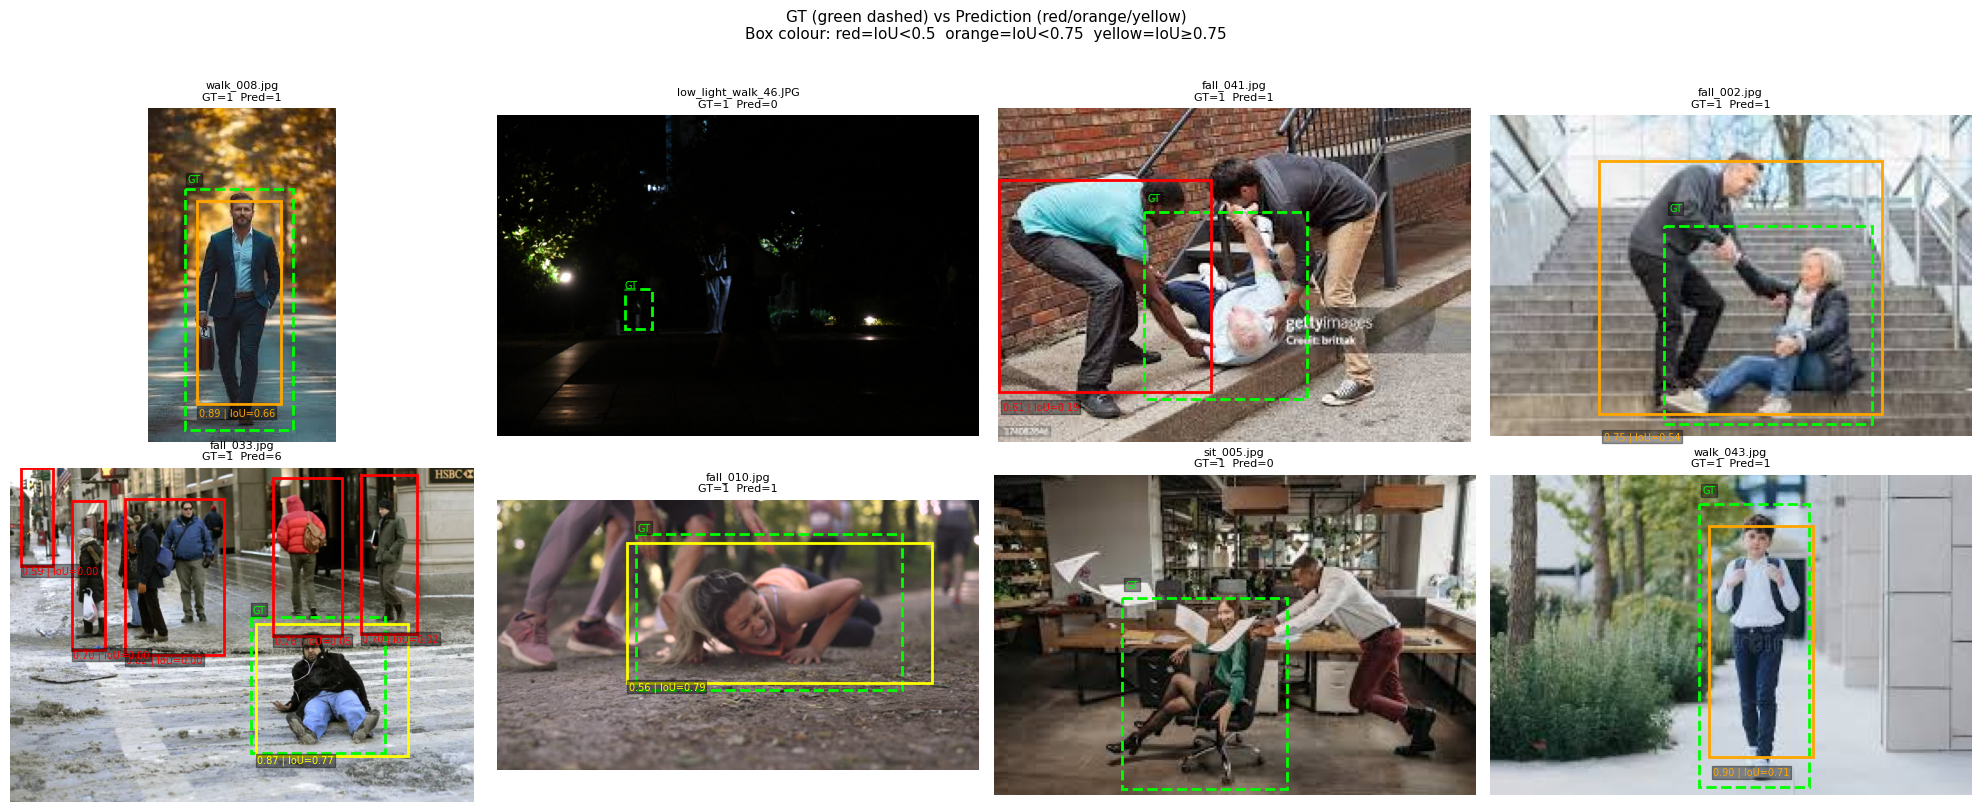

Saved → gt_vs_pred.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# Helper function to draw GT vs Pred boxes (from original cell Ltl3hCDVPUgw)
def draw_gt_vs_pred(ax, img_path, gt_cxywh, pred_xyxy_norm, scores,
                    iou_mat=None):
    img = PILImage.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)

    # draw GT boxes — GREEN
    gt_xyxy_norm = cxcywh_to_xyxy(gt_cxywh) # cxcywh_to_xyxy is defined in 2be773df
    for box in gt_xyxy_norm:
        x1,y1,x2,y2 = (box * torch.tensor([W,H,W,H])).int().tolist()
        ax.add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            lw=2, edgecolor='lime', facecolor='none', linestyle='--'))
        ax.text(x1+2, y1-6, 'GT', color='lime', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.4, pad=1))

    # draw predicted boxes — RED/ORANGE/YELLOW
    if pred_xyxy_norm.numel() > 0:
        for i, (box, score) in enumerate(zip(pred_xyxy_norm, scores)):
            x1,y1,x2,y2 = (box * torch.tensor([W,H,W,H])).int().tolist()
            # compute best IoU for this pred vs all GT
            best_iou = 0.0
            if gt_cxywh.numel() > 0 and iou_mat is not None:
                best_iou = iou_mat[i].max().item()
            iou_color = 'red' if best_iou < 0.5 else (
                         'orange' if best_iou < 0.75 else 'yellow')
            ax.add_patch(patches.Rectangle(
                (x1,y1), x2-x1, y2-y1,
                lw=2, edgecolor=iou_color, facecolor='none'))
            label = f'{score:.2f} | IoU={best_iou:.2f}'
            ax.text(x1+2, y2+10, label, color=iou_color, fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))

    n_gt   = gt_cxywh.size(0)
    n_pred = pred_xyxy_norm.size(0) if pred_xyxy_norm.numel() > 0 else 0
    ax.set_title(f'{Path(img_path).name}\nGT={n_gt}  Pred={n_pred}',
                 fontsize=8)
    ax.axis('off')


# Get per-image results from the final test evaluation
per_img = final_test['per_image'] # using final_test from cell 2be773df

# pick 8 samples: mix of good and bad IoU images (from original cell Ltl3hCDVPUgw)
good = [r for r in per_img if r['mean_iou'] >= 0.7 and r['n_gt'] > 0]
bad  = [r for r in per_img if r['mean_iou'] < 0.5  and r['n_gt'] > 0]
mid  = [r for r in per_img if 0.5 <= r['mean_iou'] < 0.7 and r['n_gt'] > 0]

samples = (
    random.sample(good, min(3, len(good))) +
    random.sample(mid,  min(2, len(mid)))  +
    random.sample(bad,  min(3, len(bad)))
)
random.shuffle(samples)
samples = samples[:8]

n_cols = 4
n_rows = (len(samples) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for ax, rec in zip(axes, samples):
    gt_cxywh = rec['gt_cxywh']
    pred_b   = rec['pred_boxes']
    scores   = rec['scores']

    # compute iou matrix for colour coding
    iou_mat = None
    if gt_cxywh.numel() > 0 and pred_b.numel() > 0:
        gt_xyxy  = cxcywh_to_xyxy(gt_cxywh)
        iou_mat  = tv_box_iou(pred_b, gt_xyxy)

    draw_gt_vs_pred(ax, rec['path'], gt_cxywh, pred_b, scores, iou_mat)

# Turn off unused axes
for ax in axes[len(samples):]:
    ax.axis('off')

fig.suptitle(
    'GT (green dashed) vs Prediction (red/orange/yellow)\n'
    'Box colour: red=IoU<0.5  orange=IoU<0.75  yellow=IoU≥0.75',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(run_dir / 'gt_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → gt_vs_pred.png')